In [31]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('messy_orders_practice.csv')

## **1. DATA CLEANING**

In [3]:
df.head()

,OrderID,OrderDate,CustomerCity,Status,Qty,PricePerUnit,Amount,DeliveryDays,PaymentMode,Country,IsPrimeMember,PrimeDeliveryType,Unnamed: 12
0,5089,15-01-2024,Ahmedabad,Delivered,5,499,2495.0,2.0,Cash on Delivery,India,Yes,One-Day,NaN
1,5127,26/06/2024,DELHI,Delivered,6,299,1794.0,9.0,Net Banking,India,No,NaN,NaN
2,5046,2024-02-28,PUNE,Delivered,6,999,5994.0,8.0,UPI,India,Yes,One-Day,NaN
3,5012,24-05-2024,chennai,Delivered,4,299,1196.0,8.0,UPI,India,Yes,One-Day,NaN
4,5053,01-02-2024,Ahmedabad,Returned,5,199,995.0,7.0,Net Banking,India,No,NaN,NaN


In [4]:
df.shape

(154, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OrderID            154 non-null    int64  
 1   OrderDate          154 non-null    str    
 2   CustomerCity       154 non-null    str    
 3   Status             154 non-null    str    
 4   Qty                154 non-null    int64  
 5   PricePerUnit       154 non-null    int64  
 6   Amount             119 non-null    float64
 7   DeliveryDays       105 non-null    float64
 8   PaymentMode        150 non-null    str    
 9   Country            154 non-null    str    
 10  IsPrimeMember      154 non-null    str    
 11  PrimeDeliveryType  83 non-null     str    
 12  Unnamed: 12        0 non-null      float64
dtypes: float64(3), int64(3), str(7)
memory usage: 22.9 KB


In [6]:
df.isnull().sum()

OrderID                0
OrderDate              0
CustomerCity           0
Status                 0
Qty                    0
PricePerUnit           0
Amount                35
DeliveryDays          49
PaymentMode            4
Country                0
IsPrimeMember          0
PrimeDeliveryType     71
Unnamed: 12          154
dtype: int64

In [7]:
df['OrderDate'].head(10)

0    15-01-2024
1    26/06/2024
2    2024-02-28
3    24-05-2024
4    01-02-2024
5    2024-02-12
6    2024-02-24
7    16-05-2024
8    2024-07-20
9    06-05-2024
Name: OrderDate, dtype: str

In [8]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='mixed', dayfirst=True)

In [9]:
df['OrderDate'].dtype
df['OrderDate'].head(20)

0    2024-01-15
1    2024-06-26
2    2024-02-28
3    2024-05-24
4    2024-02-01
5    2024-12-02
6    2024-02-24
7    2024-05-16
8    2024-07-20
9    2024-05-06
10   2024-02-01
11   2024-10-19
12   2024-04-03
13   2024-08-18
14   2024-04-22
15   2024-05-01
16   2024-04-13
17   2024-08-13
18   2024-02-17
19   2024-06-08
Name: OrderDate, dtype: datetime64[us]

In [10]:
df.duplicated().sum()

np.int64(4)

In [11]:
df[df.duplicated()]

,OrderID,OrderDate,CustomerCity,Status,Qty,PricePerUnit,Amount,DeliveryDays,PaymentMode,Country,IsPrimeMember,PrimeDeliveryType,Unnamed: 12
71,5015,2024-05-06,pune,Cancelled,2,1499,NaN,NaN,Cash on Delivery,India,No,NaN,NaN
113,5017,2024-12-03,Bangalore,Delivered,5,999,4995.0,4.0,Net Banking,India,Yes,One-Day,NaN
137,5076,2024-05-19,CHENNAI,Delivered,2,1999,3998.0,5.0,Net Banking,India,Yes,One-Day,NaN
151,5099,2024-01-15,CHENNAI,Cancelled,6,1499,NaN,NaN,UPI,India,No,NaN,NaN


In [12]:
df = df.drop_duplicates()
df.duplicated().sum()
df.shape

(150, 13)

In [13]:
df.nunique()

OrderID              150
OrderDate            121
CustomerCity          28
Status                 4
Qty                    6
PricePerUnit           7
Amount                40
DeliveryDays          10
PaymentMode            5
Country                1
IsPrimeMember          2
PrimeDeliveryType      1
Unnamed: 12            0
dtype: int64

In [14]:
df.groupby('IsPrimeMember')['PrimeDeliveryType'].value_counts(dropna=False)

IsPrimeMember  PrimeDeliveryType
No             NaN                  69
Yes            One-Day              81
Name: count, dtype: int64

In [15]:
df = df.drop(columns=['Country', 'Unnamed: 12', 'PrimeDeliveryType'])

In [16]:
df.columns.tolist()

['OrderID',
 'OrderDate',
 'CustomerCity',
 'Status',
 'Qty',
 'PricePerUnit',
 'Amount',
 'DeliveryDays',
 'PaymentMode',
 'IsPrimeMember']

In [17]:
df[df['Amount'].isnull()]['Status'].value_counts()

Status
Cancelled    33
Name: count, dtype: int64

In [18]:
df[df['DeliveryDays'].isnull()]['Status'].value_counts()

Status
Cancelled    33
Pending      14
Name: count, dtype: int64

In [19]:
df['DeliveryDays'].dtype

dtype('float64')

In [20]:
df[df['PaymentMode'].isnull()]['Status'].value_counts()

Status
Delivered    2
Cancelled    2
Name: count, dtype: int64

In [21]:
df['PaymentMode'] = df['PaymentMode'].fillna('Unknown')

In [22]:
df.isnull().sum()

OrderID           0
OrderDate         0
CustomerCity      0
Status            0
Qty               0
PricePerUnit      0
Amount           33
DeliveryDays     47
PaymentMode       0
IsPrimeMember     0
dtype: int64

## **2. EDA**

### **A)Do Prime members have a higher average order value than non-Prime members?**

In [23]:
prime_avg_spend = df.groupby('IsPrimeMember')['Amount'].mean()
prime_avg_spend

IsPrimeMember
No     2972.481481
Yes    3175.730159
Name: Amount, dtype: float64

In [24]:
df['IsPrimeMember'].value_counts()

IsPrimeMember
Yes    81
No     69
Name: count, dtype: int64

### **INSIGHT**
- Prime members show a higher average order value (₹3,175.73) compared to non-Prime members (₹2,972.48) — a difference of ~₹203, or about 6.3%. With a reasonably balanced sample size (81 Prime vs 69 non-Prime orders), this difference appears to be a genuine pattern rather than a small-sample artifact, suggesting Prime membership may be associated with modestly higher spending per order

#### **B)Delivery Time Per City**

In [26]:
df['CustomerCity'].unique()

<ArrowStringArray>
['Ahmedabad',     'DELHI',      'PUNE',   'chennai',   'Chennai',   'KOLKATA',
 'Hyderabad',      'pune',    'Madras',   'Kolkata',     'Delhi', 'bangalore',
  'Calcutta', 'Bangalore', 'ahmedabad',    'mumbai',      'Pune',   'CHENNAI',
    'Bombay',    'MUMBAI',     'delhi', 'HYDERABAD', 'hyderabad', 'Bengaluru',
 'BANGALORE', 'New Delhi',    'Mumbai', 'AHMEDABAD']
Length: 28, dtype: str

### Data Cleaning task 
- So here we have a issue that there are some cities which are same and have names in lower and upper cases 
- Also there are some cities which have there old name and new name together which will cause an issue in the insight 

In [27]:
df['CustomerCity'] = df['CustomerCity'].str.title()


In [28]:
df['CustomerCity'].unique()

<ArrowStringArray>
['Ahmedabad',     'Delhi',      'Pune',   'Chennai',   'Kolkata', 'Hyderabad',
    'Madras', 'Bangalore',  'Calcutta',    'Mumbai',    'Bombay', 'Bengaluru',
 'New Delhi']
Length: 13, dtype: str

In [29]:
# map the alternate names to their modern/standard name, using a dictionary + .replace():
city_mapping = {
    'Madras': 'Chennai',
    'Calcutta': 'Kolkata',
    'Bombay': 'Mumbai',
    'Bengaluru': 'Bangalore',
    'New Delhi': 'Delhi',
}
df['CustomerCity'] = df['CustomerCity'].replace(city_mapping)

In [30]:
df['CustomerCity'].unique()

<ArrowStringArray>
['Ahmedabad',     'Delhi',      'Pune',   'Chennai',   'Kolkata', 'Hyderabad',
 'Bangalore',    'Mumbai']
Length: 8, dtype: str

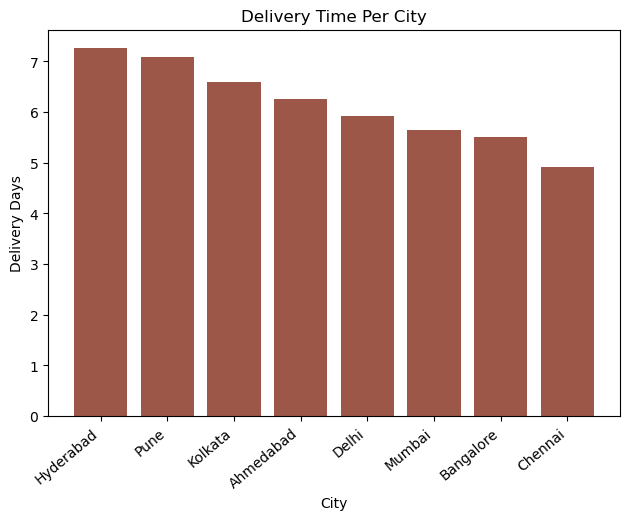

In [37]:
delivery_time = df.groupby('CustomerCity')['DeliveryDays'].mean()
delivery_time = delivery_time.sort_values(ascending=False)
plt.bar(delivery_time.index , delivery_time.values , color = '#9C5748')
plt.xlabel('City')
plt.ylabel('Delivery Days')
plt.title('Delivery Time Per City')
plt.tight_layout()
plt.xticks(rotation = 40 , ha = 'right')
plt.show()